In [11]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [12]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [13]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... Press Ctrl+C now to interrupt!")
    try:
        # Break sleep into 1-second chunks to make it interruptible
        for i in range(100):
            time.sleep(1)
            if i % 10 == 0:
                print(f"  ⏳ Still waiting... ({i}s elapsed)")
    except KeyboardInterrupt:
        print("  ⚠️ Step 2 interrupted! State will be saved.")
        raise  # Re-raise to let LangGraph handle the interruption
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}


In [14]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

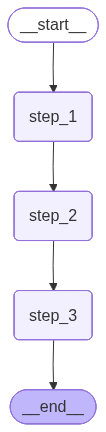

In [15]:
graph

In [16]:
# 4. Run the graph (this will crash at step 2)
initial_state = {"input": "test"}
print("🚀 Starting the graph...")
result = graph.invoke(initial_state, config={"configurable": {"thread_id": "thread-1"}})
print("✅ Graph completed:", result)

🚀 Starting the graph...
✅ Step 1 executed
⏳ Step 2 hanging... Press Ctrl+C now to interrupt!
  ⏳ Still waiting... (0s elapsed)
  ⏳ Still waiting... (10s elapsed)
  ⏳ Still waiting... (20s elapsed)
  ⚠️ Step 2 interrupted! State will be saved.


KeyboardInterrupt: 

In [17]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'test', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267ac-f789-6096-8001-54ab5ef066b2'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-23T05:40:33.384652+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267ac-f786-63e1-8000-00b165290ec1'}}, tasks=(PregelTask(id='81bc115e-ae3d-7d99-d5cd-7836777d21aa', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [18]:
#  Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... Press Ctrl+C now to interrupt!
  ⏳ Still waiting... (0s elapsed)
  ⏳ Still waiting... (10s elapsed)
  ⏳ Still waiting... (20s elapsed)
  ⏳ Still waiting... (30s elapsed)
  ⏳ Still waiting... (40s elapsed)
  ⏳ Still waiting... (50s elapsed)
  ⏳ Still waiting... (60s elapsed)
  ⏳ Still waiting... (70s elapsed)
  ⏳ Still waiting... (80s elapsed)
  ⏳ Still waiting... (90s elapsed)
✅ Step 3 executed

✅ Final State: {'input': 'test', 'step1': 'done', 'step2': 'done'}


In [19]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'test', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267b2-9c47-672f-8003-259db152ce01'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-23T05:43:04.877023+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267b2-9c45-667c-8002-e3fbd2d33e25'}}, tasks=(), interrupts=())

In [20]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'test', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267b2-9c47-672f-8003-259db152ce01'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-23T05:43:04.877023+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267b2-9c45-667c-8002-e3fbd2d33e25'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'test', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267b2-9c45-667c-8002-e3fbd2d33e25'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-23T05:43:04.876182+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1267ac-f789-6096-8001-54ab5ef066b2'}}, tasks=(PregelTask(id='63ec1506-9b27-c3c8-7fb1-31b0237a38ff'